<a href="https://colab.research.google.com/github/solankiboy939/Deep_Learning/blob/main/CNN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [4]:
# 1. Load MNIST datset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

#Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
#2. Built CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 classes for digit 0-9
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"]
              )


In [7]:
# 4 Train model
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 49ms/step - accuracy: 0.8739 - loss: 0.4443 - val_accuracy: 0.9817 - val_loss: 0.0548
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.9822 - loss: 0.0587 - val_accuracy: 0.9861 - val_loss: 0.0416
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.9878 - loss: 0.0393 - val_accuracy: 0.9850 - val_loss: 0.0433
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 47ms/step - accuracy: 0.9912 - loss: 0.0298 - val_accuracy: 0.9890 - val_loss: 0.0317
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9927 - loss: 0.0229 - val_accuracy: 0.9901 - val_loss: 0.0291


In [8]:
#Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 3s - 10ms/step - accuracy: 0.9901 - loss: 0.0291
Test accuracy: 0.9901


(0.5, 1.0)

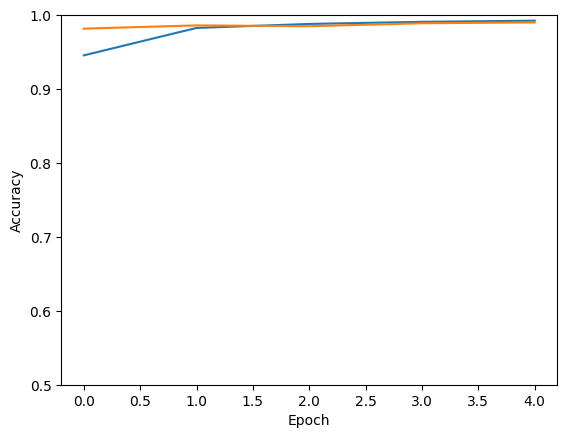

In [9]:
# plot training history (oprional)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])